
# Statistical Analysis of Earthquake Magnitude and Depth Distribution

# Overview

This project presents a statistical analysis workflow for earthquake catalog data associated with the Indian tectonic plate region.

The notebook includes:

- Earthquake magnitude distribution analysis
- Earthquake depth classification
- Temporal earthquake catalogue filtering
- High-magnitude earthquake extraction
- Statistical summary generation
- Export of processed datasets

The workflow is designed for:

- Seismicity characterization
- Earthquake catalogue preprocessing
- Statistical seismology studies
- Regional tectonic investigations
- Machine learning preprocessing pipelines


# Scientific Objectives

The primary objectives of this study are:

- Analyze earthquake magnitude-frequency distribution
- Classify earthquakes based on focal depth
- Filter earthquake catalogues for selected time periods
- Identify major seismic events
- Prepare processed seismic datasets for advanced analysis

The generated statistical summaries can support:

- Seismic hazard studies
- Seismotectonic analysis
- Earthquake forecasting
- Spatial-temporal seismicity analysis


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option('display.max_columns', None)

## 2. Load Earthquake Catalogue

In [3]:
# Read earthquake catalogue

df = pd.read_csv(
    '/content/drive/MyDrive/Project 4/usgs_data_3.csv'
)

# Display first few rows

df.head()

,LON,LAT,Year,Month,Date,MAG,DEPTH,Hour,Minutes,Time (years)
0,-155.166000,19.068500,1966,1,1,3.0,3.875,6,2,1966.0027
1,-155.208333,19.093500,1966,1,1,2.9,9.805,6,24,1966.0027
2,-155.285667,19.319000,1966,1,1,2.7,0.905,6,28,1966.0027
3,-78.249000,42.842000,1966,1,1,4.3,NaN,13,23,1966.0027
4,-155.216167,19.336333,1966,1,1,2.5,-0.345,20,37,1966.0027


In [4]:
# Rename column MAG to Magnitude

df = df.rename(columns={'MAG': 'Magnitude'})

In [5]:
# Rename column MAG to Magnitude

df = df.rename(columns={'DEPTH': 'Depth'})

## 3. Dataset Information

In [6]:
# Total earthquake events

print(f'Total earthquake events: {len(df)}')

# Display column names

print(df.columns)

# Dataset summary

df.info()

Total earthquake events: 61374
Index(['LON', 'LAT', 'Year', 'Month', 'Date', 'Magnitude', 'Depth', 'Hour',
       'Minutes', 'Time (years)'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61374 entries, 0 to 61373
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   LON           61374 non-null  float64
 1   LAT           61374 non-null  float64
 2   Year          61374 non-null  int64  
 3   Month         61374 non-null  int64  
 4   Date          61374 non-null  int64  
 5   Magnitude     61374 non-null  float64
 6   Depth         61355 non-null  float64
 7   Hour          61374 non-null  int64  
 8   Minutes       61374 non-null  int64  
 9   Time (years)  61374 non-null  float64
dtypes: float64(5), int64(5)
memory usage: 4.7 MB


In [7]:
df

,LON,LAT,Year,Month,Date,Magnitude,Depth,Hour,Minutes,Time (years)
0,-155.166000,19.068500,1966,1,1,3.0,3.875,6,2,1966.0027
1,-155.208333,19.093500,1966,1,1,2.9,9.805,6,24,1966.0027
2,-155.285667,19.319000,1966,1,1,2.7,0.905,6,28,1966.0027
3,-78.249000,42.842000,1966,1,1,4.3,NaN,13,23,1966.0027
4,-155.216167,19.336333,1966,1,1,2.5,-0.345,20,37,1966.0027
...,...,...,...,...,...,...,...,...,...,...
61369,-155.108167,19.334500,1975,12,31,2.6,8.868,23,37,1976.0000
61370,-122.905667,38.787000,1975,12,31,1.5,2.869,23,44,1976.0000
61371,-89.530000,36.470000,1975,12,31,1.2,5.000,23,45,1976.0000
61372,145.062000,18.691000,1975,12,31,5.3,580.000,23,56,1976.0000


# Magnitude Distribution Analysis

Earthquake events are classified into different magnitude ranges to understand seismic activity patterns.


## 4. Compute Magnitude Distribution

In [8]:
# Count earthquake events within magnitude ranges

magnitude_counts = {
    '1 <= Mw < 2': len(df[(df['Magnitude'] >= 1) & (df['Magnitude'] < 2)]),
    '2 <= Mw < 3': len(df[(df['Magnitude'] >= 2) & (df['Magnitude'] < 3)]),
    '3 <= Mw < 4': len(df[(df['Magnitude'] >= 3) & (df['Magnitude'] < 4)]),
    '4 <= Mw < 5': len(df[(df['Magnitude'] >= 4) & (df['Magnitude'] < 5)]),
    '5 <= Mw < 6': len(df[(df['Magnitude'] >= 5) & (df['Magnitude'] < 6)]),
    '6 <= Mw < 7': len(df[(df['Magnitude'] >= 6) & (df['Magnitude'] < 7)]),
    '7 <= Mw < 8': len(df[(df['Magnitude'] >= 7) & (df['Magnitude'] < 8)]),
    '8 <= Mw < 9': len(df[(df['Magnitude'] >= 8) & (df['Magnitude'] < 9)]),
    'Mw >= 9': len(df[df['Magnitude'] >= 9])
}

# Convert to DataFrame

magnitude_df = pd.DataFrame(
    list(magnitude_counts.items()),
    columns=['Magnitude Range', 'Number of Events']
)

magnitude_df

,Magnitude Range,Number of Events
0,1 <= Mw < 2,13617
1,2 <= Mw < 3,24328
2,3 <= Mw < 4,6068
3,4 <= Mw < 5,6003
4,5 <= Mw < 6,9930
5,6 <= Mw < 7,1285
6,7 <= Mw < 8,136
7,8 <= Mw < 9,7
8,Mw >= 9,0


## 5. Visualize Magnitude Distribution

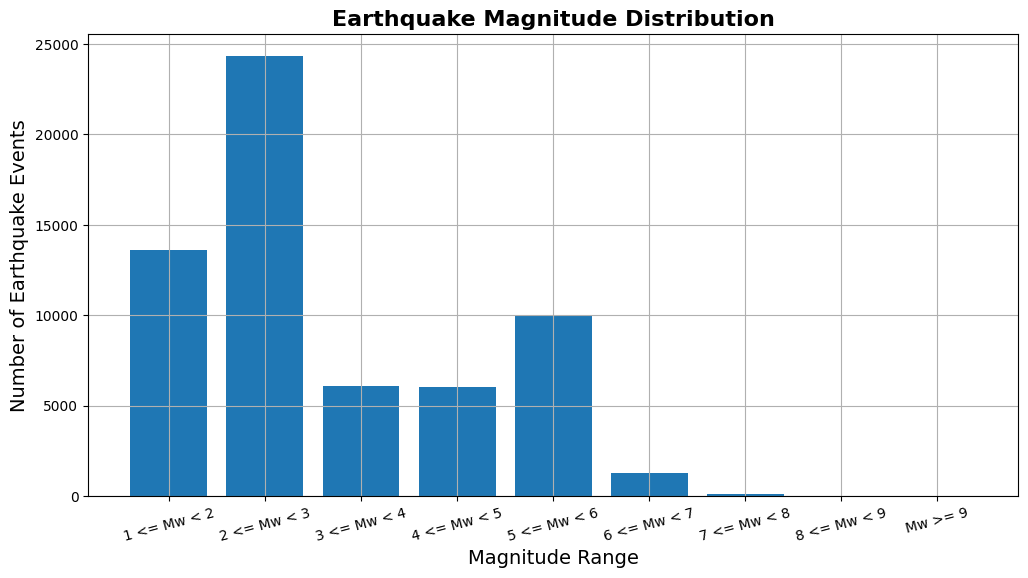

In [9]:
plt.figure(figsize=(12, 6))

plt.bar(
    magnitude_df['Magnitude Range'],
    magnitude_df['Number of Events']
)

plt.xlabel('Magnitude Range', fontsize=14)
plt.ylabel('Number of Earthquake Events', fontsize=14)

plt.title(
    'Earthquake Magnitude Distribution',
    fontsize=16,
    fontweight='bold'
)

plt.xticks(rotation=15)

plt.grid(True)

plt.show()

# Depth Distribution Analysis

Earthquakes are classified into shallow, intermediate, and deep-focus events based on focal depth.


## 6. Compute Depth Distribution

In [10]:
# Count earthquake events based on depth ranges

depth_counts = {
    'D < 70 km': len(df[df['Depth'] < 70]),
    '70 <= D < 300 km': len(df[(df['Depth'] >= 70) & (df['Depth'] < 300)]),
    'D >= 300 km': len(df[df['Depth'] >= 300])
}

# Convert to DataFrame

depth_df = pd.DataFrame(
    list(depth_counts.items()),
    columns=['Depth Range', 'Number of Events']
)

depth_df

,Depth Range,Number of Events
0,D < 70 km,57189
1,70 <= D < 300 km,3300
2,D >= 300 km,866


## 7. Visualize Depth Distribution

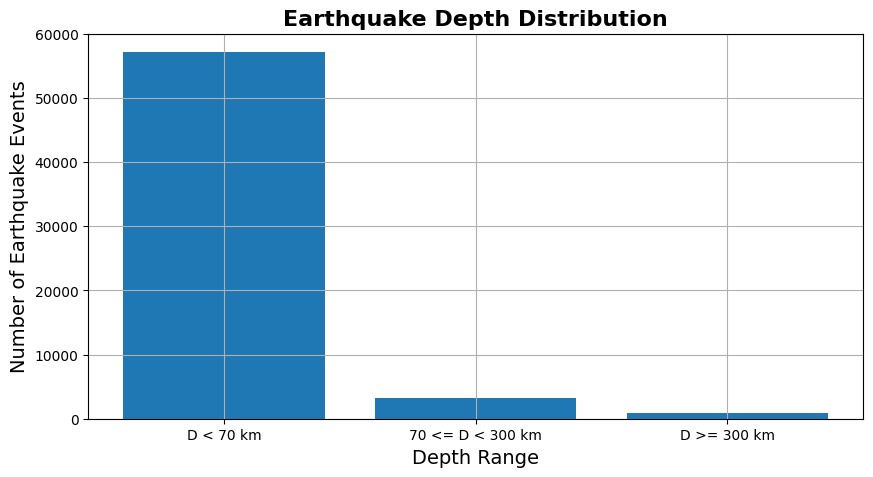

In [11]:
plt.figure(figsize=(10, 5))

plt.bar(
    depth_df['Depth Range'],
    depth_df['Number of Events']
)

plt.xlabel('Depth Range', fontsize=14)
plt.ylabel('Number of Earthquake Events', fontsize=14)

plt.title(
    'Earthquake Depth Distribution',
    fontsize=16,
    fontweight='bold'
)

plt.grid(True)

plt.show()

# Temporal Earthquake Catalogue Filtering

The following section filters earthquake events occurring after the year 1960.


## 8. Filter Earthquake Catalogue after 1960

In [15]:
# Filter catalogue

df_after_1960 = df[
    df['Year'] > 1960
]

# Display filtered catalogue

df_after_1960.head()

,LON,LAT,Year,Month,Date,Magnitude,Depth,Hour,Minutes,Time (years)
0,-155.166000,19.068500,1966,1,1,3.0,3.875,6,2,1966.0027
1,-155.208333,19.093500,1966,1,1,2.9,9.805,6,24,1966.0027
2,-155.285667,19.319000,1966,1,1,2.7,0.905,6,28,1966.0027
3,-78.249000,42.842000,1966,1,1,4.3,NaN,13,23,1966.0027
4,-155.216167,19.336333,1966,1,1,2.5,-0.345,20,37,1966.0027


## 9. Save Output in csv

In [16]:
df_after_1960.to_csv("/content/drive/MyDrive/Project 5/output.csv", index=False)

# High-Magnitude Earthquake Extraction

The following section extracts major earthquakes with moment magnitude greater than or equal to 8.


### 10. Extract Major Earthquakes

In [17]:
# Extract major earthquakes

major_earthquakes = df[
    df['Magnitude'] >= 8
]

# Display extracted earthquakes

major_earthquakes

,LON,LAT,Year,Month,Date,Magnitude,Depth,Hour,Minutes,Time (years)
1190,-78.228,-10.665,1966,10,17,8.1,40.0,21,42,1966.7957
3689,143.435,40.860,1968,5,16,8.2,29.9,0,49,1968.3763
6730,147.814,43.416,1969,8,11,8.2,28.6,21,27,1969.6129
10431,-72.532,-1.597,1970,7,31,8.0,644.8,17,8,1970.5833
14647,153.850,-5.524,1971,7,14,8.0,40.0,6,11,1971.5376
14856,153.172,-4.817,1971,7,26,8.1,40.0,1,23,1971.5699
21422,126.640,6.405,1972,12,2,8.0,60.0,0,19,1972.9220


## 11. Statistical Summary

In [18]:
# Summary statistics

df[['Magnitude', 'Depth']].describe()

,Magnitude,Depth
count,61374.000000,61355.000000
mean,3.082346,26.457510
std,1.453915,66.949395
min,1.000000,-3.144000
25%,2.000000,4.253000
50%,2.500000,7.505000
75%,4.500000,27.000000
max,8.200000,692.000000


# Applications

The developed workflow can be applied in:

- Statistical seismology
- Seismic hazard analysis
- Earthquake recurrence studies
- Seismotectonic investigations
- Earthquake forecasting
- Machine learning preprocessing
- Regional seismicity characterization


# References

1. Hanks, T. C., & Kanamori, H. (1979). A moment magnitude scale.

2. Choy, G. L., & Boatwright, J. (1995). Global patterns of radiated seismic energy and apparent stress.

3. Yarramsetty, B. B., & Kavitha, B. (2025). Statistical Study on Seismicity of the Indian Tectonic Plate Interactions.

4. Yarramsetty, B. B., & Baladhandapani, K. (2026). Data-driven prediction of global annual seismic energy using machine learning models.


# Conclusion

This notebook successfully demonstrates:

- Earthquake magnitude-frequency analysis
- Depth classification of seismic events
- Temporal earthquake catalogue filtering
- High-magnitude earthquake extraction
- Statistical seismicity characterization

The generated workflow provides a strong foundation for advanced seismic hazard assessment and AI-driven seismicity analysis.
